Discrimination of Binary Coherent States (BPSK) from the Kennedy Receiver to the Quantum Helstrom Bound & Dolinar Circuit

# 1. Theoretical Framework & Fundamental Bounds
In optical quantum communications, information is encoded into two non-orthogonal coherent states of light: 
 $$|\psi_0\rangle = |+\alpha\rangle \quad (\text{Bit } 0), \qquad |\psi_1\rangle = |-\alpha\rangle \quad (\text{Bit } 1)$$

Because the two states have a non-zero quantum overlap:
 
$$\langle -\alpha | +\alpha \rangle = e^{-2|\alpha|^2} \neq 0$$
 
it is fundamentally impossible to distinguish them with certainty. The minimum average error probability permitted by quantum mechanics is given by the Helstrom Bound:
 
$$P_e^{\text{Helstrom}} = \frac{1}{2}\left(1 - \sqrt{1 - e^{-4|\alpha|^2}}\right)$$

## The Kennedy Receiver (Displacement & Photon Counting)

The Kennedy receiver is a quantum detection scheme designed to surpass the homodyne receiver without requiring Gaussian measurements. 
Instead of measuring the field quadrature, it uses a two-step strategy:
-  Coherent Displacement $D(\alpha)$: It interferes the incoming state with a Local Oscillator to intentionally cancel out the state $|-\alpha\rangle$, shifting it to the vacuum state $|0\rangle$, while doubling the amplitude of $|+\alpha\rangle$:
   $$D(\alpha)|-\alpha\rangle = |0\rangle \quad (\text{Vacuum})$$
   $$D(\alpha)|+\alpha\rangle = |+2\alpha\rangle \quad (\text{Amplified State})$$
- On/Off Single-Photon Detection (SPD): A single-photon detector simply checks whether at least one photon was detected ($n \ge 1$, a "click") or no photons were detected ($n = 0$, "no click").

As a decision rule, if $n = 0$ (no click), we decide that the state was $|-\alpha\rangle$ (Bit 1), since it was shifted to vacuum; and if $n \ge 1$ (click), we decide that the state sent was $|+\alpha\rangle$ (Bit 0), since vacuum cannot generate photons.
There is however an error, where if we don't get a click, we assume it was the vaccum state and it's the Bit 1. However, the bit 0 has a non-zero probability of not getting a click either, but we always assume that if we don't get a click, no photon was measured and we sent the Bit 1, which may not always be the case.
Since it's a Poisson distribution:

$|+\alpha\rangle$: The detector sees $|+2\alpha\rangle$ with mean photon number $\mu = |2\alpha|^2 = 4|\alpha|^2$. An error occurs only if this state Poisson-fluctuates to 0 detected photons:
  $$P(\text{error} \mid +\alpha) = P(n = 0 \mid 2\alpha) = e^{-\mu} = e^{-4|\alpha|^2}$$

Assuming equiprobable bits ($P(0) = P(1) = 0.5$):

$$P_e^{\text{Kennedy}} = \frac{1}{2}(0) + \frac{1}{2} e^{-4|\alpha|^2} = \frac{1}{2} e^{-4|\alpha|^2}$$

In [3]:
#Imports

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
from scipy.optimize import brentq
import qutip as qt

# Plotting the theoredical curves

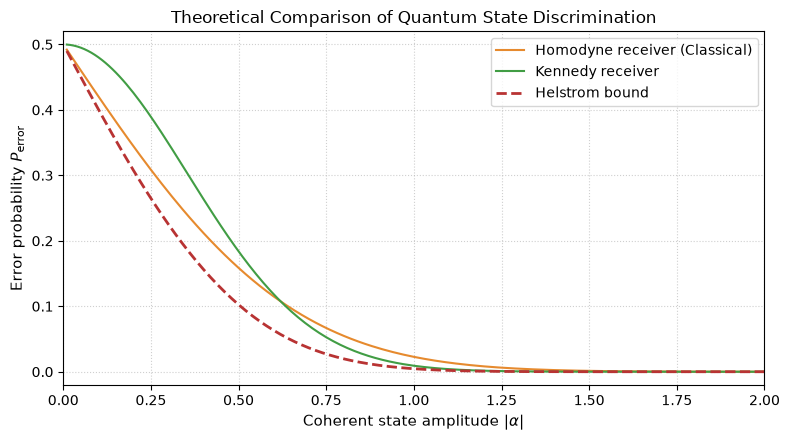

In [4]:
# Array of coherent state alpha amplitudes for theoretical curves 
alphas = np.linspace(0.01, 2.0, 200)

# Theoretical Error Curves
p_helstrom = 0.5 * (1.0 - np.sqrt(1.0 - np.exp(-4.0 * (alphas**2)))) 
p_kennedy  = 0.5 * np.exp(-4.0 * (alphas**2))
p_homodyne = 0.5 * erfc(np.sqrt(2.0) * alphas)

plt.figure(figsize=(8, 4.5))
plt.plot(alphas, p_homodyne, '-', label='Homodyne receiver (Classical)', color='#e68a2e')
plt.plot(alphas, p_kennedy, '-', label='Kennedy receiver', color='#419d44')
plt.plot(alphas, p_helstrom, '--', label='Helstrom bound', color='#b83333', linewidth=2)

plt.xlabel(r'Coherent state amplitude $|\alpha|$', fontsize=11)
plt.ylabel(r'Error probability $P_{\mathrm{error}}$', fontsize=11)
plt.title('Theoretical Comparison of Quantum State Discrimination', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)
plt.xlim(0, 2.0)
plt.ylim(-0.02, 0.52)
plt.tight_layout()
plt.show()

# The Kennedy Receiver: Displacement Operator $D(\beta)$
The Kennedy receiver applies a displacement $D(\beta = \alpha)$ to cancel the hypothesis $|-\alpha\rangle \to |0\rangle$ while mapping $|+\alpha\rangle \to |+2\alpha\rangle$. 

An On/Off Single-Photon Detector (SPD) then counts photons:
- If **$n = 0$ photons** are detected $\implies$ Decide $|-\alpha\rangle$ (Bit 1).
- If **$n \ge 1$ photons** are detected $\implies$ Decide $|+\alpha\rangle$ (Bit 0).

In [5]:
N_dim = 35     #Fock state
alpha_val = 0.8  #Chose one just for illustration of the Kennedy receiver

# Coherent states in Hilbert space
psi_plus  = qt.coherent(N_dim, alpha_val)
psi_minus = qt.coherent(N_dim, -alpha_val)

# Kennedy Displacement D(alpha)
D_op = qt.displace(N_dim, alpha_val)
displaced_plus  = D_op * psi_plus   # displaces the |+alpha> state to |2*alpha>
displaced_minus = D_op * psi_minus  # displaced to |0> (Vacuum)

In [8]:
# Photon number statistics
P_plus_n  = np.abs(displaced_plus.full().flatten())**2   #probability distribution of detecting n photons when |+α> was sent
P_minus_n = np.abs(displaced_minus.full().flatten())**2   #probability distribution of detecting n photons when |-α> was sent


P_plus_0_analytical = np.exp(-4.0 * (alpha_val**2))  # theoredical probability of detecting 0 photons when |+α> was sent 

print(f"Probability of detecting 0 photons when |+α> was sent: {P_plus_n[0]}")
print(f"Analytical probability of detecting 0 photons when |+α> was sent: {P_plus_0_analytical}")

Probability of detecting 0 photons when |+α> was sent: 0.07730474044329966
Analytical probability of detecting 0 photons when |+α> was sent: 0.07730474044329971


When $|+\alpha\rangle$ is transmitted, the Kennedy receiver applies the displacement $D(\alpha)$, shifting the state to $|+2\alpha\rangle$. The probability of mistakenly recording **$0$ photons** (a miss error) follows Poisson statistics with mean photon number $\mu = |2\alpha|^2 = 4|\alpha|^2$:

$$P(n = 0 \mid +\alpha) = e^{-4|\alpha|^2}$$

For $\alpha = 0.8$:
* Analytical value: $e^{-4(0.8)^2} = e^{-2.56} \approx 0.07730474044329971$
* Numerical value (QuTiP Hilbert space): $\approx 0.07730474044329966$

The numerical simulation matches the analytical derivation with an absolute difference on the order of $\sim 10^{-16}$, validating the truncation dimension $N$ and the displacement operator representation in the Fock basis.

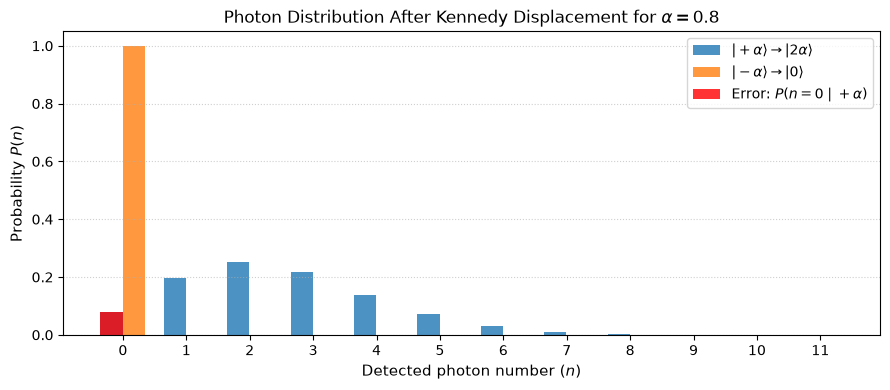

In [10]:
n_values = np.arange(N_dim)
plt.figure(figsize=(9, 4))
plt.bar(n_range - 0.18, P_plus_n[n_range], width=0.35, label=r'$|+\alpha\rangle \to |2\alpha\rangle$', color='#1f77b4', alpha=0.8)
plt.bar(n_range + 0.18, P_minus_n[n_range], width=0.35, label=r'$|-\alpha\rangle \to |0\rangle$', color='#ff7f0e', alpha=0.8)

# Highlight error on bit 1 (detecting 0 photons when |+alpha> was sent)
plt.bar(0 - 0.18, P_plus_n[0], width=0.35, color='red', alpha=0.8, label=r'Error: $P(n=0 \mid +\alpha)$')

plt.xlabel('Detected photon number ($n$)', fontsize=11)
plt.ylabel('Probability $P(n)$', fontsize=11)
plt.title(f'Photon Distribution After Kennedy Displacement for $\\alpha={alpha_val}$', fontsize=12)
plt.xticks(n_range)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


The bar chart illustrates the fundamental operating principle and error mechanism of the Kennedy Receiver for $\alpha = 0.8$:

* **State $|-\alpha\rangle \to |0\rangle$ (Orange):** Shifting by $+\alpha$ turns this state into pure vacuum. The detector sees $0$ photons $100\%$ of the time ($P=1.0$).
* **State $|+\alpha\rangle \to |2\alpha\rangle$ (Blue):** Shifting by $+\alpha$ doubles its amplitude. The photon count follows a Poisson distribution with an average of $\bar{n} = 4(0.8)^2 = 2.56$ photons.
* **The Only Error Source (Red):** The receiver only makes a mistake when $|+\alpha\rangle$ generates 0 photons by chance. This happens with probability $P(n=0 \mid +\alpha) = e^{-4(0.8)^2} \approx 7.7\%$.

# Optimized Displacement Kennedy Receiver ($\beta_{\text{opt}}$)
Instead of strict cancellation $\beta = \alpha$, tuning $\beta > \alpha$ allows a small non-zero false alarm probability $P(n \ge 1 \mid -\alpha)$ in exchange for a significantly reduced miss probability $P(n = 0 \mid +\alpha)$, strictly outperforming the standard Kennedy receiver.


### Mathematical Derivation of the Optimal Displacement $\beta_{\text{opt}}$

In the standard Kennedy receiver, the displacement is fixed to $\beta = \alpha$, yielding a zero false-alarm rate but a fixed miss error. If an arbitrary displacement $\beta > \alpha$ is allowed:

* $|+\alpha\rangle$ shifted to $|\alpha + \beta\rangle$: $P(n=0 \mid +\alpha) = e^{-(\alpha + \beta)^2}$
* $|-\alpha\rangle$ shifted to $|-\alpha + \beta\rangle$: $P(n \ge 1 \mid -\alpha) = 1 - e^{-(\beta - \alpha)^2}$

Assuming equiprobable hypotheses, the total error probability is:
$$P_e(\beta) = \frac{1}{2}\left[ e^{-(\alpha + \beta)^2} + 1 - e^{-(\beta - \alpha)^2} \right]$$

To find the optimal value $\beta_{\text{opt}}$, take the derivative with respect to $\beta$ and set it to zero:
$$\frac{dP_e}{d\beta} = -(\alpha + \beta)e^{-(\alpha + \beta)^2} + (\beta - \alpha)e^{-(\beta - \alpha)^2} = 0$$

Rearranging the exponential terms:
$$\frac{\beta + \alpha}{\beta - \alpha} = \frac{e^{-(\beta - \alpha)^2}}{e^{-(\alpha + \beta)^2}} = e^{(\alpha + \beta)^2 - (\beta - \alpha)^2} = e^{4\alpha\beta}$$

Taking the natural logarithm on both sides yields the transcendental equation:
$$g(\beta) = 4\alpha\beta - \ln\left(\frac{\beta + \alpha}{\beta - \alpha}\right) = 0$$

The function "get_optimal_beta(a)" solves $g(\beta) = 0$ numerically.

In [11]:
def get_optimal_beta(a):     #Finding the beta that minimizes the Kennedy error probability for a given alpha
    if a > 3.0:
        return a   #it was just making error so we added xd
    g = lambda b: 4.0 * a * b - np.log((b + a) / (b - a))  #creating a function g(b) whose root will give us the optimal beta
                                                           # derivation of the kennedy error probability with respect to 
                                                           # beta and setting it to zero gives us the equation g(b) = 0

    small_infisitesimal_alpha = np.nextafter(a, np.inf)   #lower bound for the root finding, slightly greater than a to avoid division by zero in g(b)
    return brentq(g, small_infisitesimal_alpha, 3.0 * a + 1.0)  #solving the equation g(b) = 0 for beta in the range (a, 3a+1)


def simulate_kennedy_error(N_space, a_in, beta_disp=None):
    if beta_disp is None:
        beta_disp = a_in
    p_state = qt.coherent(N_space, a_in)
    m_state = qt.coherent(N_space, -a_in)
    
    D = qt.displace(N_space, beta_disp)
    p_shifted = D * p_state
    m_shifted = D * m_state
    
    p0_given_plus  = np.abs(p_shifted.full()[0][0])**2  
    p0_given_minus = np.abs(m_shifted.full()[0][0])**2  #Now this one is not zero, because we are not displacing to the vacuum state anymore, 
                                                        #but to |beta> which is not orthogonal to |0>
    
    return 0.5 * p0_given_plus + 0.5 * (1.0 - p0_given_minus)

alphas_eval = np.linspace(0.1, 2.0, 50)  #list of alpha values for which we want to evaluate the Kennedy error probability
p_std_kennedy = [simulate_kennedy_error(N_dim, a) for a in alphas_eval]  #calculating the Kennedy error probability for each alpha using the standard displacement (beta = alpha)
p_opt_kennedy = [simulate_kennedy_error(N_dim, a, get_optimal_beta(a)) for a in alphas_eval]  #calculating the Kennedy error probability for each alpha using the optimal displacement

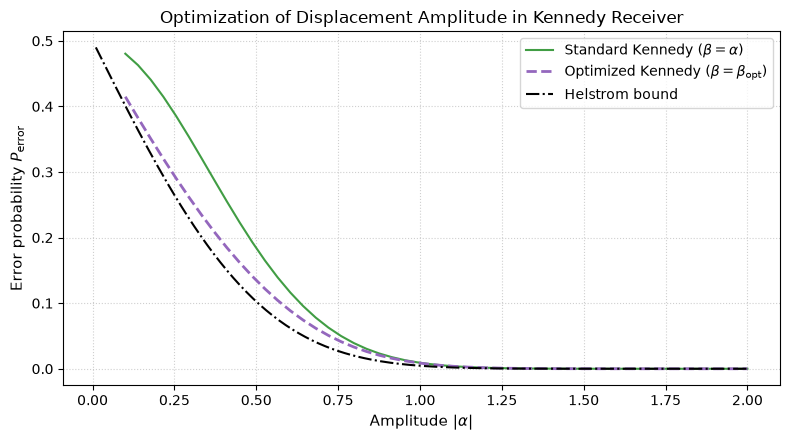

In [12]:
#Plot
plt.figure(figsize=(8, 4.5))
plt.plot(alphas_eval, p_std_kennedy, '-', label='Standard Kennedy ($\\beta=\\alpha$)', color='#419d44')
plt.plot(alphas_eval, p_opt_kennedy, '--', label='Optimized Kennedy ($\\beta=\\beta_{\\mathrm{opt}}$)', color='#9467bd', linewidth=2)
plt.plot(alphas, p_helstrom, 'k-.', label='Helstrom bound', linewidth=1.5)

plt.xlabel(r'Amplitude $|\alpha|$', fontsize=11)
plt.ylabel(r'Error probability $P_{\mathrm{error}}$', fontsize=11)
plt.title('Optimization of Displacement Amplitude in Kennedy Receiver', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

We can see that for the standard Kennedy where the displacement is equal to the amplitude of the coeherent state, we get the error much larger than the quantum bound Helstrom.
When looking at the optimazation of the displacement, we see that the error is smaller when we optimize it this way.